# **Customer Segmentation Using RFM Analysis and Unsupervised Machine Learning**

## **Project Overview**

This notebook presents a complete customer segmentation pipeline applied to a real-world
e-commerce transactional dataset. The project combines classical marketing theory with
modern machine learning techniques to identify distinct customer groups based on
purchasing behavior.

The analysis is grounded in the RFM framework (Recency, Frequency, Monetary), a
well-established model in consumer behavior and direct marketing literature. Unsupervised
learning algorithms including K-Means, Hierarchical Clustering, and DBSCAN are applied
to derive actionable customer segments.

## **Research Relevance**

Customer segmentation is a foundational problem in consumer behavior and market
segmentation research. This project addresses the following academic questions:

- How can transactional data be transformed into behavioral customer profiles?
- Which clustering algorithm produces the most meaningful and stable segments?
- What managerial implications can be drawn from data-driven segmentation?

## **Dataset**

Source: UCI Machine Learning Repository via Kaggle
Link: https://www.kaggle.com/datasets/carrie1/ecommerce-data
Description: Transnational dataset of online retail transactions from a UK-based
company between 01/12/2010 and 09/12/2011.

## Notebook Structure

1. Environment Setup and Library Imports
2. Data Loading and Initial Inspection
3. Data Cleaning and Preprocessing
4. Exploratory Data Analysis (EDA)
5. RFM Feature Engineering
6. RFM Scoring and Customer Profiling
7. Data Preparation for Clustering
8. K-Means Clustering
9. Hierarchical Clustering
10. DBSCAN Clustering
11. Cluster Comparison and Evaluation
12. Business Interpretation and Managerial Insights
13. Project Summary

## **Section 1: Environment Setup and Library Imports**

We begin by importing all necessary libraries for data manipulation, visualization,
statistical analysis, and machine learning. All dependencies are pre-installed in
Google Colab except for one additional library used for cluster visualization.

In [1]:
# Install additional library for enhanced cluster visualization
!pip install yellowbrick --quiet

# Data manipulation
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Statistical analysis
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist

# Machine learning - Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler

# Machine learning - Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Machine learning - Evaluation
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score

# Cluster visualization
from yellowbrick.cluster import SilhouetteVisualizer, KElbowVisualizer

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

# Plot style
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["figure.dpi"] = 100

print("All libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully.
Pandas version: 2.2.2
NumPy version: 2.0.2


## **Section 2: Data Loading and Initial Inspection**

The dataset is fetched directly from Kaggle using the Kaggle API. To authenticate,
you must upload your kaggle.json API token file which can be downloaded from your
Kaggle account settings under the API section.

To download the E-Commerce dataset directly into Google Colab, follow these steps:

1. Go to your Kaggle account settings: https://www.kaggle.com/settings
2. Scroll to the API section and click "Create New Token"
3. A file named kaggle.json will be downloaded to your computer
4. Upload it when the cell below prompts you

In [2]:
# Step 1: Upload your kaggle.json file
from google.colab import files

print("Please upload your kaggle.json file")
files.upload()

print("Kaggle API key configured successfully.")

Please upload your kaggle.json file


Saving kaggle.json to kaggle.json
Kaggle API key configured successfully.


In [3]:
# Step 2: Configure Kaggle API credentials and download dataset
import os

# Set up kaggle credentials directory
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API key configured successfully.")

# Download the dataset
!kaggle datasets download -d carrie1/ecommerce-data --unzip -p /content/data

print("Dataset downloaded and extracted successfully.")
print("\nFiles in /content/data:")
for f in os.listdir("/content/data"):
    print(f"  - {f}")

Kaggle API key configured successfully.
Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
100% 7.20M/7.20M [00:00<00:00, 108MB/s]

Dataset downloaded and extracted successfully.

Files in /content/data:
  - data.csv


In [5]:
# Step 3: Load dataset and perform initial inspection
df = pd.read_csv("/content/data/data.csv", encoding="ISO-8859-1")

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

DATASET SHAPE
Rows    : 541,909
Columns : 8


In [6]:
print("\n" + "=" * 60)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 60)
print(df.dtypes)


COLUMN NAMES AND DATA TYPES
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [7]:
print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
df.head()


FIRST 5 ROWS


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.5500,17850.0000,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.3900,17850.0000,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.7500,17850.0000,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.3900,17850.0000,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.3900,17850.0000,United Kingdom


## **Section 3: Data Cleaning and Preprocessing**

Before any analysis, we assess and resolve data quality issues. This includes
identifying missing values, removing cancelled transactions, filtering invalid
records, and converting columns to their correct data types.

The following cleaning steps are applied in sequence:

- Identify and document missing values in each column
- Remove rows with missing CustomerID as they cannot be used for segmentation
- Convert InvoiceDate from string to datetime format
- Remove cancelled transactions identified by InvoiceNo starting with "C"
- Remove rows where Quantity or UnitPrice is zero or negative
- Remove duplicate rows
- Document the impact of each cleaning step on dataset size

In [11]:
# Step 4: Missing value assessment
print("=" * 60)
print("MISSING VALUES ASSESSMENT")
print("=" * 60)

missing = pd.DataFrame({
    "Missing Count" : df.isnull().sum(),
    "Missing Percent": (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing)

MISSING VALUES ASSESSMENT
             Missing Count  Missing Percent
InvoiceNo                0           0.0000
StockCode                0           0.0000
Description           1454           0.2700
Quantity                 0           0.0000
InvoiceDate              0           0.0000
UnitPrice                0           0.0000
CustomerID          135080          24.9300
Country                  0           0.0000


In [12]:
print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
print(f"Duplicate rows: {df.duplicated().sum():,}")


DUPLICATE ROWS
Duplicate rows: 5,268


In [13]:
print("\n" + "=" * 60)
print("BASIC STATISTICS - QUANTITY AND UNITPRICE")
print("=" * 60)
print(df[["Quantity", "UnitPrice"]].describe())


BASIC STATISTICS - QUANTITY AND UNITPRICE
         Quantity   UnitPrice
count 541909.0000 541909.0000
mean       9.5522      4.6111
std      218.0812     96.7599
min   -80995.0000 -11062.0600
25%        1.0000      1.2500
50%        3.0000      2.0800
75%       10.0000      4.1300
max    80995.0000  38970.0000


In [14]:
print("\n" + "=" * 60)
print("CANCELLED TRANSACTIONS")
print("=" * 60)
cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")]
print(f"Cancelled transactions: {len(cancelled):,}")
print(f"Percentage of total   : {len(cancelled)/len(df)*100:.2f}%")


CANCELLED TRANSACTIONS
Cancelled transactions: 9,288
Percentage of total   : 1.71%


In [10]:
# Step 5: Record original shape before cleaning
original_shape = df.shape[0]
print(f"Original dataset rows: {original_shape:,}")

Original dataset rows: 541,909


In [15]:
# Step 6: Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

print(f"Rows removed due to missing CustomerID : {541909 - len(df):,}")
print(f"Remaining rows                         : {len(df):,}")

Rows removed due to missing CustomerID : 135,080
Remaining rows                         : 406,829


In [16]:
# Step 7: Remove duplicate rows
df = df.drop_duplicates()

print(f"Rows removed due to duplicates : {406829 - len(df):,}")
print(f"Remaining rows                 : {len(df):,}")

Rows removed due to duplicates : 5,225
Remaining rows                 : 401,604


In [17]:
# Step 8: Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print(f"Rows removed due to cancellations : {401604 - len(df):,}")
print(f"Remaining rows                    : {len(df):,}")

Rows removed due to cancellations : 8,872
Remaining rows                    : 392,732


In [18]:
# Step 9: Remove rows with zero or negative Quantity and UnitPrice
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

print(f"Rows removed due to invalid Quantity or UnitPrice : {392732 - len(df):,}")
print(f"Remaining rows                                    : {len(df):,}")

Rows removed due to invalid Quantity or UnitPrice : 40
Remaining rows                                    : 392,692


In [19]:
# Step 10: Convert InvoiceDate to datetime and CustomerID to integer
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype(int)

print("Data type conversions applied successfully.")
print(f"\nInvoiceDate dtype : {df['InvoiceDate'].dtype}")
print(f"CustomerID dtype  : {df['CustomerID'].dtype}")
print(f"\nDate range:")
print(f"  Earliest transaction : {df['InvoiceDate'].min()}")
print(f"  Latest transaction   : {df['InvoiceDate'].max()}")

Data type conversions applied successfully.

InvoiceDate dtype : datetime64[ns]
CustomerID dtype  : int64

Date range:
  Earliest transaction : 2010-12-01 08:26:00
  Latest transaction   : 2011-12-09 12:50:00


In [20]:
# Step 11: Final cleaning summary
print("=" * 60)
print("DATA CLEANING SUMMARY")
print("=" * 60)
print(f"Original dataset rows       : {541909:,}")
print(f"Missing CustomerID removed  : {135080:,}")
print(f"Duplicate rows removed      : {5225:,}")
print(f"Cancelled transactions      : {8872:,}")
print(f"Invalid Quantity/UnitPrice  : {40:,}")
print(f"Final dataset rows          : {len(df):,}")
print(f"Total rows removed          : {541909 - len(df):,}")
print(f"Data retained               : {len(df)/541909*100:.2f}%")

print("\n" + "=" * 60)
print("FINAL DATASET INFO")
print("=" * 60)
print(df.dtypes)
print(f"\nUnique customers  : {df['CustomerID'].nunique():,}")
print(f"Unique invoices   : {df['InvoiceNo'].nunique():,}")
print(f"Unique products   : {df['StockCode'].nunique():,}")
print(f"Unique countries  : {df['Country'].nunique():,}")

DATA CLEANING SUMMARY
Original dataset rows       : 541,909
Missing CustomerID removed  : 135,080
Duplicate rows removed      : 5,225
Cancelled transactions      : 8,872
Invalid Quantity/UnitPrice  : 40
Final dataset rows          : 392,692
Total rows removed          : 149,217
Data retained               : 72.46%

FINAL DATASET INFO
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

Unique customers  : 4,338
Unique invoices   : 18,532
Unique products   : 3,665
Unique countries  : 37


## **Section 4: Exploratory Data Analysis**

Before building the RFM model, we explore the dataset to understand the distribution
of transactions, revenue patterns, customer activity, and geographic spread. This
section provides the statistical foundation for the segmentation analysis.

In [21]:
# Step 12: Create TotalAmount column for revenue analysis
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

print("=" * 60)
print("REVENUE STATISTICS")
print("=" * 60)
print(f"Total revenue generated     : GBP {df['TotalAmount'].sum():,.2f}")
print(f"Average order value         : GBP {df.groupby('InvoiceNo')['TotalAmount'].sum().mean():,.2f}")
print(f"Average revenue per customer: GBP {df.groupby('CustomerID')['TotalAmount'].sum().mean():,.2f}")
print(f"Maximum single transaction  : GBP {df['TotalAmount'].max():,.2f}")
print(f"Minimum single transaction  : GBP {df['TotalAmount'].min():,.2f}")

print("\n" + "=" * 60)
print("TRANSACTIONS PER MONTH")
print("=" * 60)
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly = df.groupby("YearMonth")["InvoiceNo"].nunique()
print(monthly)

REVENUE STATISTICS
Total revenue generated     : GBP 8,887,208.89
Average order value         : GBP 479.56
Average revenue per customer: GBP 2,048.69
Maximum single transaction  : GBP 168,469.60
Minimum single transaction  : GBP 0.00

TRANSACTIONS PER MONTH
YearMonth
2010-12    1400
2011-01     987
2011-02     997
2011-03    1321
2011-04    1149
2011-05    1555
2011-06    1393
2011-07    1331
2011-08    1280
2011-09    1755
2011-10    1929
2011-11    2657
2011-12     778
Freq: M, Name: InvoiceNo, dtype: int64


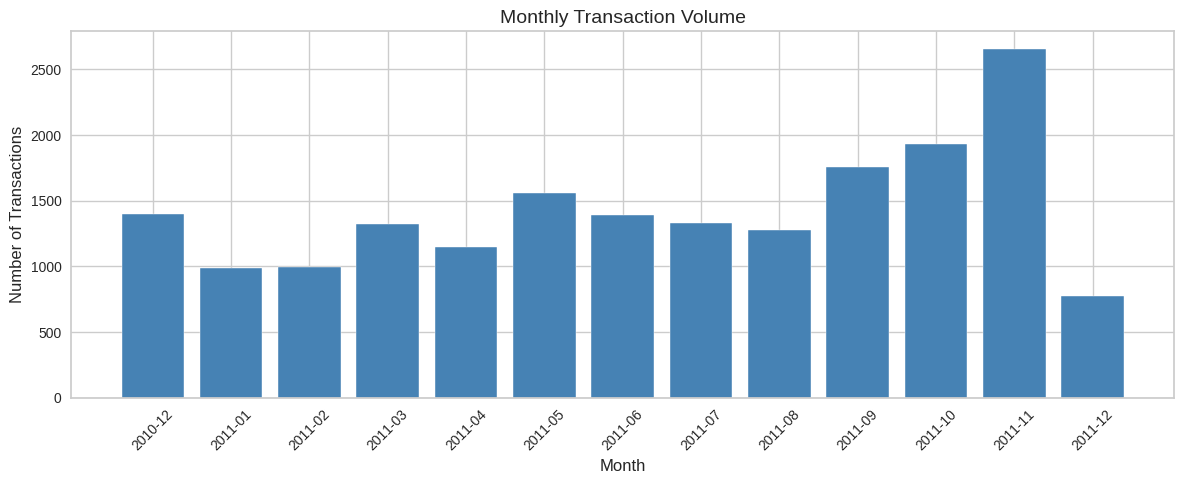

In [22]:
# Step 13: Plot monthly transaction volume
monthly_df = monthly.reset_index()
monthly_df["YearMonth"] = monthly_df["YearMonth"].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(monthly_df["YearMonth"], monthly_df["InvoiceNo"], color="steelblue", edgecolor="white")
plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

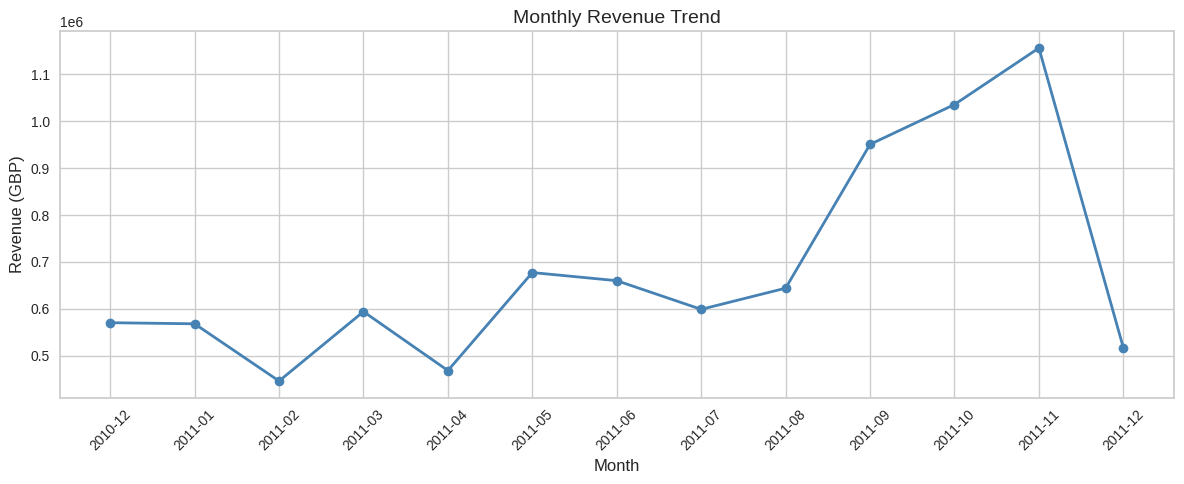

In [23]:
# Step 14: Plot monthly revenue trend
monthly_revenue = df.groupby("YearMonth")["TotalAmount"].sum().reset_index()
monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["TotalAmount"],
         color="steelblue", marker="o", linewidth=2)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (GBP)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

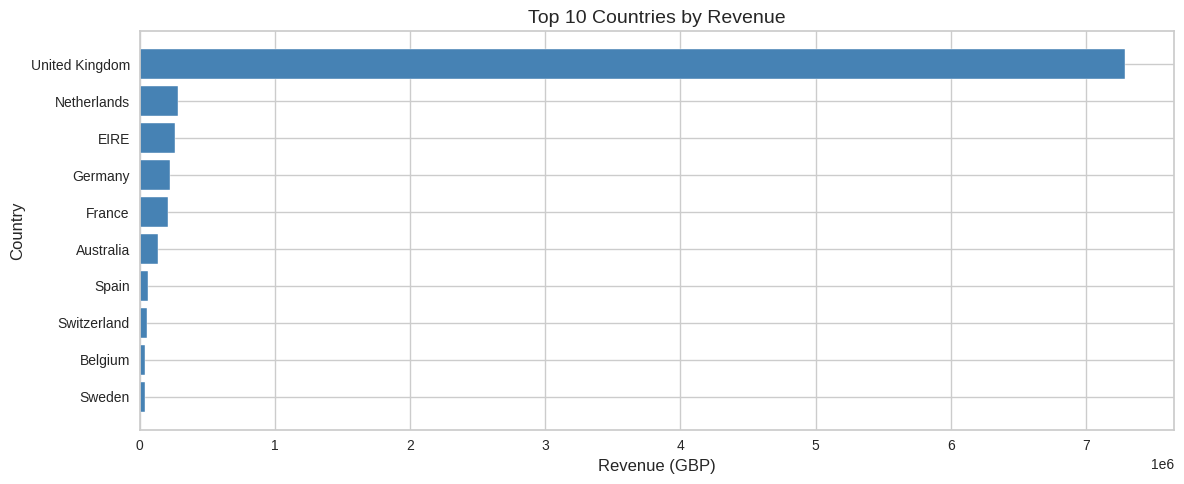

In [24]:
# Step 15: Plot top 10 countries by revenue
top_countries = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.barh(top_countries.index, top_countries.values, color="steelblue", edgecolor="white")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (GBP)")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

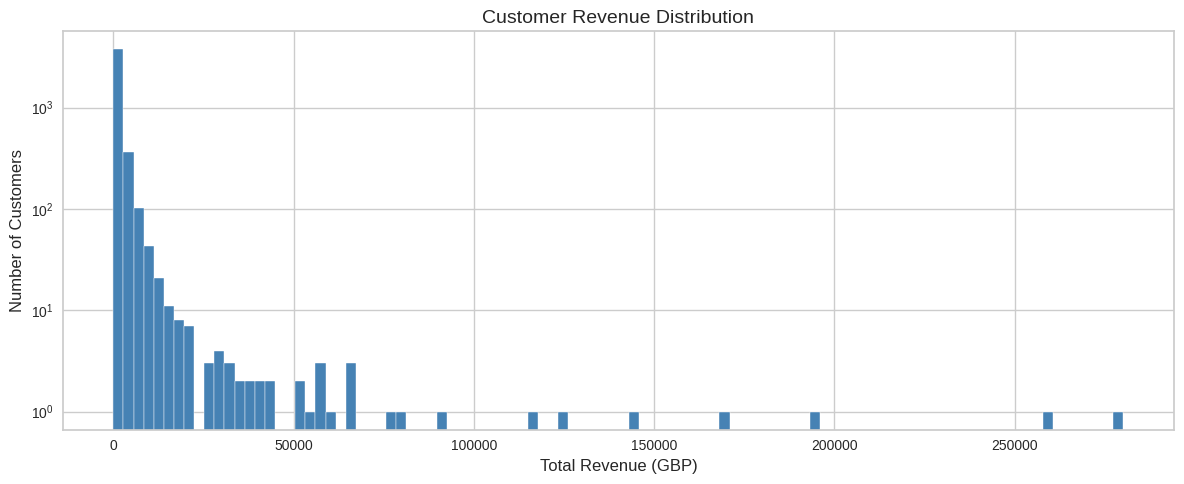

In [25]:
# Step 16: Plot customer revenue distribution
customer_revenue = df.groupby("CustomerID")["TotalAmount"].sum()

plt.figure(figsize=(12, 5))
plt.hist(customer_revenue, bins=100, color="steelblue", edgecolor="white")
plt.title("Customer Revenue Distribution")
plt.xlabel("Total Revenue (GBP)")
plt.ylabel("Number of Customers")
plt.yscale("log")
plt.tight_layout()
plt.show()

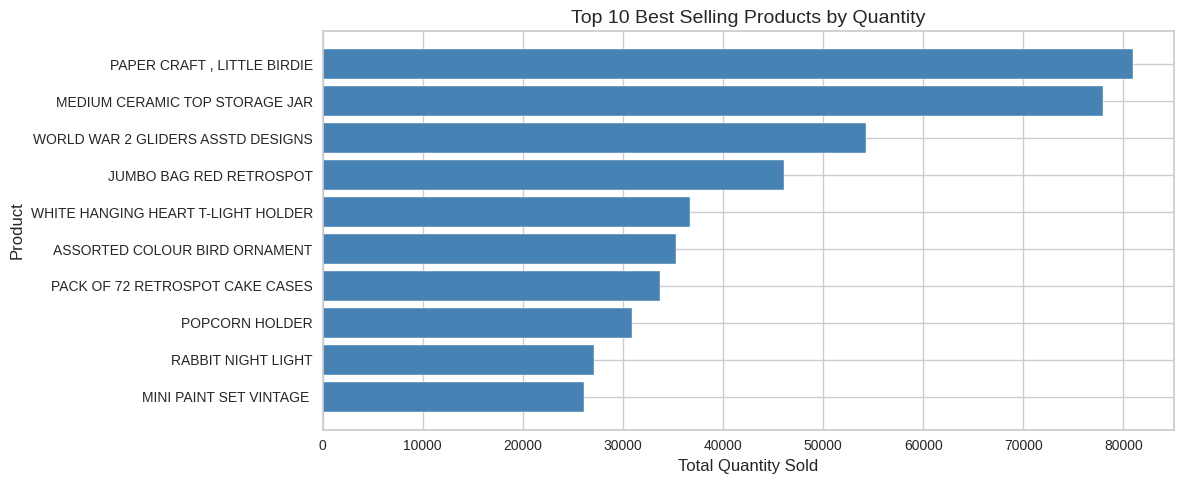

In [26]:
# Step 17: Top 10 best selling products by quantity
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.barh(top_products.index, top_products.values, color="steelblue", edgecolor="white")
plt.title("Top 10 Best Selling Products by Quantity")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## **Section 5: RFM Feature Engineering**

RFM is a behavior-based customer segmentation technique rooted in direct marketing
literature. It evaluates customers along three dimensions:

- Recency (R)   : How recently did the customer make a purchase?
                  Measured as the number of days between the customer's last
                  purchase and a defined reference date.

- Frequency (F) : How often does the customer purchase?
                  Measured as the total number of unique invoices per customer.

- Monetary (M)  : How much does the customer spend?
                  Measured as the total revenue generated per customer.

The reference date is set to one day after the last transaction in the dataset
to ensure all customers have a recency value of at least 1.

In [27]:
# Step 18: Define reference date
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(f"Latest transaction date : {df['InvoiceDate'].max()}")
print(f"Reference date          : {reference_date}")

Latest transaction date : 2011-12-09 12:50:00
Reference date          : 2011-12-10 12:50:00


In [28]:
# Step 19: Compute RFM metrics per customer
rfm = df.groupby("CustomerID").agg(
    Recency   = ("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency = ("InvoiceNo", "nunique"),
    Monetary  = ("TotalAmount", "sum")
).reset_index()

print("=" * 60)
print("RFM TABLE - FIRST 5 ROWS")
print("=" * 60)
print(rfm.head())

print("\n" + "=" * 60)
print("RFM DESCRIPTIVE STATISTICS")
print("=" * 60)
print(rfm[["Recency", "Frequency", "Monetary"]].describe())

RFM TABLE - FIRST 5 ROWS
   CustomerID  Recency  Frequency   Monetary
0       12346      326          1 77183.6000
1       12347        2          7  4310.0000
2       12348       75          4  1797.2400
3       12349       19          1  1757.5500
4       12350      310          1   334.4000

RFM DESCRIPTIVE STATISTICS
        Recency  Frequency    Monetary
count 4338.0000  4338.0000   4338.0000
mean    92.5364     4.2720   2048.6881
std    100.0142     7.6980   8985.2302
min      1.0000     1.0000      3.7500
25%     18.0000     1.0000    306.4825
50%     51.0000     2.0000    668.5700
75%    142.0000     5.0000   1660.5975
max    374.0000   209.0000 280206.0200


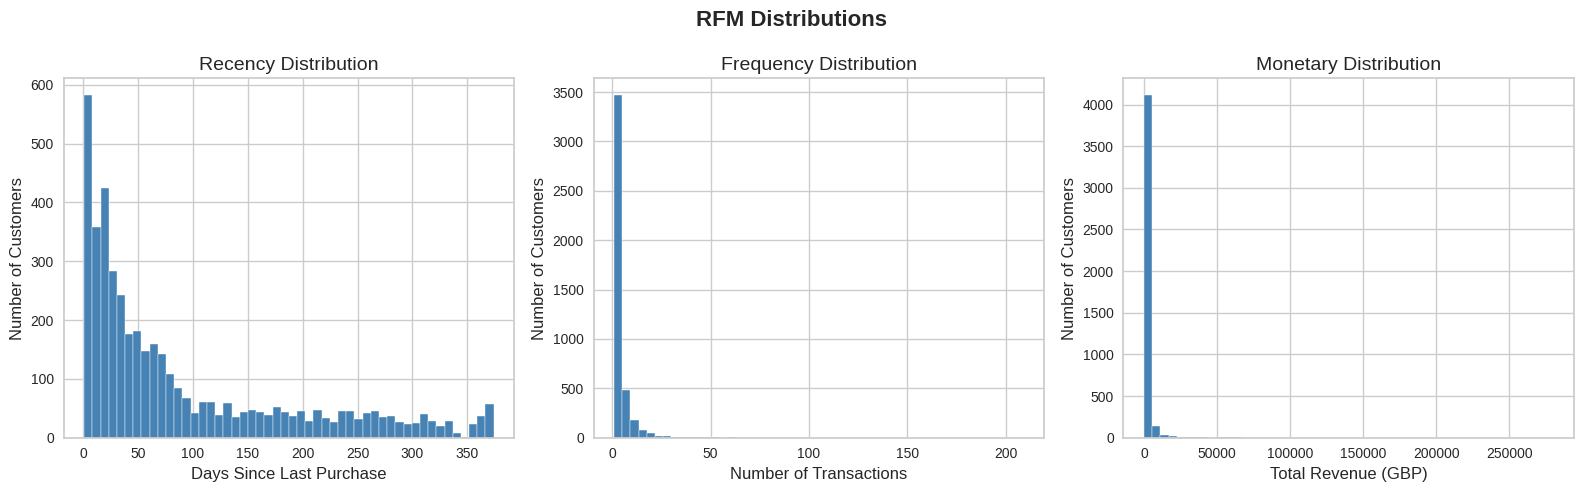

In [29]:
# Step 20: Plot RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(rfm["Recency"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days Since Last Purchase")
axes[0].set_ylabel("Number of Customers")

axes[1].hist(rfm["Frequency"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Transactions")
axes[1].set_ylabel("Number of Customers")

axes[2].hist(rfm["Monetary"], bins=50, color="steelblue", edgecolor="white")
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Revenue (GBP)")
axes[2].set_ylabel("Number of Customers")

plt.suptitle("RFM Distributions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [30]:
# Step 21: Apply log transformation to reduce skewness
rfm["Recency_log"]   = np.log1p(rfm["Recency"])
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_log"]  = np.log1p(rfm["Monetary"])

print("=" * 60)
print("SKEWNESS BEFORE LOG TRANSFORMATION")
print("=" * 60)
print(f"Recency   : {rfm['Recency'].skew():.4f}")
print(f"Frequency : {rfm['Frequency'].skew():.4f}")
print(f"Monetary  : {rfm['Monetary'].skew():.4f}")

print("\n" + "=" * 60)
print("SKEWNESS AFTER LOG TRANSFORMATION")
print("=" * 60)
print(f"Recency   : {rfm['Recency_log'].skew():.4f}")
print(f"Frequency : {rfm['Frequency_log'].skew():.4f}")
print(f"Monetary  : {rfm['Monetary_log'].skew():.4f}")

SKEWNESS BEFORE LOG TRANSFORMATION
Recency   : 1.2460
Frequency : 12.0670
Monetary  : 19.3394

SKEWNESS AFTER LOG TRANSFORMATION
Recency   : -0.3792
Frequency : 1.2087
Monetary  : 0.3966


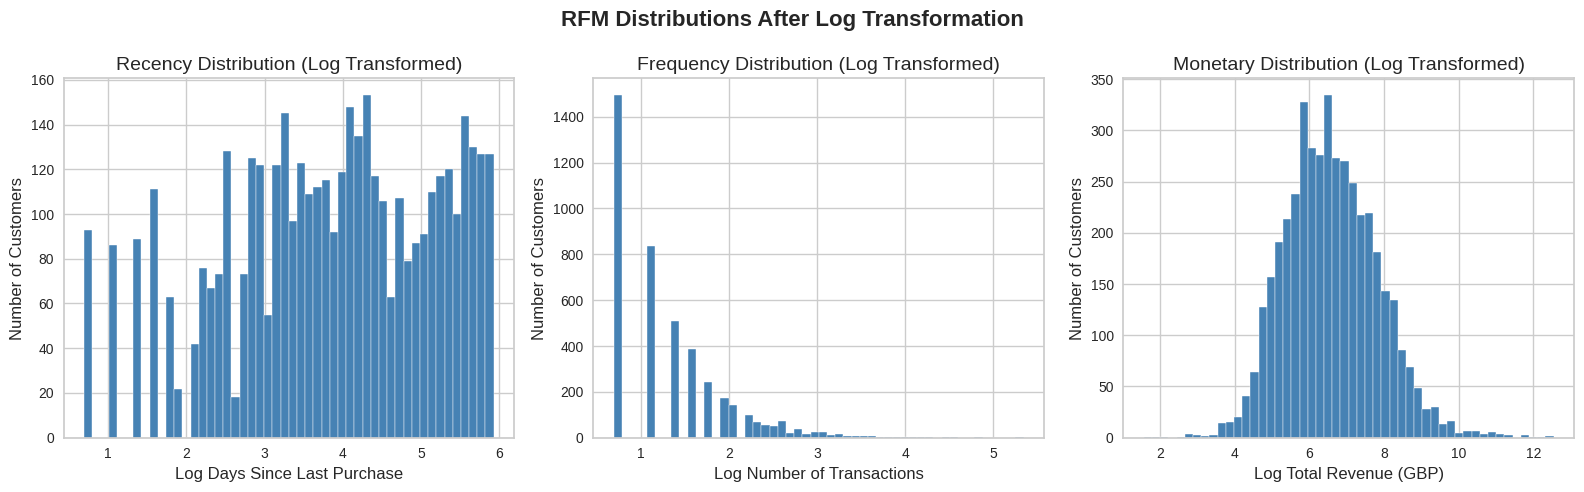

In [31]:
# Step 22: Plot RFM distributions after log transformation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(rfm["Recency_log"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Recency Distribution (Log Transformed)")
axes[0].set_xlabel("Log Days Since Last Purchase")
axes[0].set_ylabel("Number of Customers")

axes[1].hist(rfm["Frequency_log"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Frequency Distribution (Log Transformed)")
axes[1].set_xlabel("Log Number of Transactions")
axes[1].set_ylabel("Number of Customers")

axes[2].hist(rfm["Monetary_log"], bins=50, color="steelblue", edgecolor="white")
axes[2].set_title("Monetary Distribution (Log Transformed)")
axes[2].set_xlabel("Log Total Revenue (GBP)")
axes[2].set_ylabel("Number of Customers")

plt.suptitle("RFM Distributions After Log Transformation", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [32]:
# Step 23: Scale the log transformed RFM features
scaler = RobustScaler()

rfm_scaled = scaler.fit_transform(rfm[["Recency_log", "Frequency_log", "Monetary_log"]])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=["Recency_scaled", "Frequency_scaled", "Monetary_scaled"])

print("=" * 60)
print("SCALED RFM - DESCRIPTIVE STATISTICS")
print("=" * 60)
print(rfm_scaled.describe())

print("\n" + "=" * 60)
print("SCALING COMPLETE")
print("=" * 60)
print(f"Scaler used : RobustScaler")
print(f"Reason      : RobustScaler is less sensitive to outliers")
print(f"              than StandardScaler, which suits retail data")
print(f"Shape       : {rfm_scaled.shape}")

SCALED RFM - DESCRIPTIVE STATISTICS
       Recency_scaled  Frequency_scaled  Monetary_scaled
count       4338.0000         4338.0000        4338.0000
mean          -0.0597            0.2248           0.0486
std            0.6640            0.6218           0.7459
min           -1.6142           -0.3691          -2.9331
25%           -0.4988           -0.3691          -0.4613
50%            0.0000            0.0000          -0.0000
75%            0.5012            0.6309           0.5387
max            0.9788            3.8671           3.5781

SCALING COMPLETE
Scaler used : RobustScaler
Reason      : RobustScaler is less sensitive to outliers
              than StandardScaler, which suits retail data
Shape       : (4338, 3)


## **Section 6: K-Means Clustering**

K-Means is an iterative partitioning algorithm that assigns each customer to the
nearest cluster centroid based on Euclidean distance. Before fitting the model,
we determine the optimal number of clusters using two methods:

- Elbow Method : Plots inertia (within-cluster sum of squares) against number
                 of clusters. The optimal k is at the point where the curve
                 begins to flatten.

- Silhouette Score : Measures how similar a customer is to its own cluster
                     compared to other clusters. Score ranges from -1 to 1
                     where higher values indicate better defined clusters.

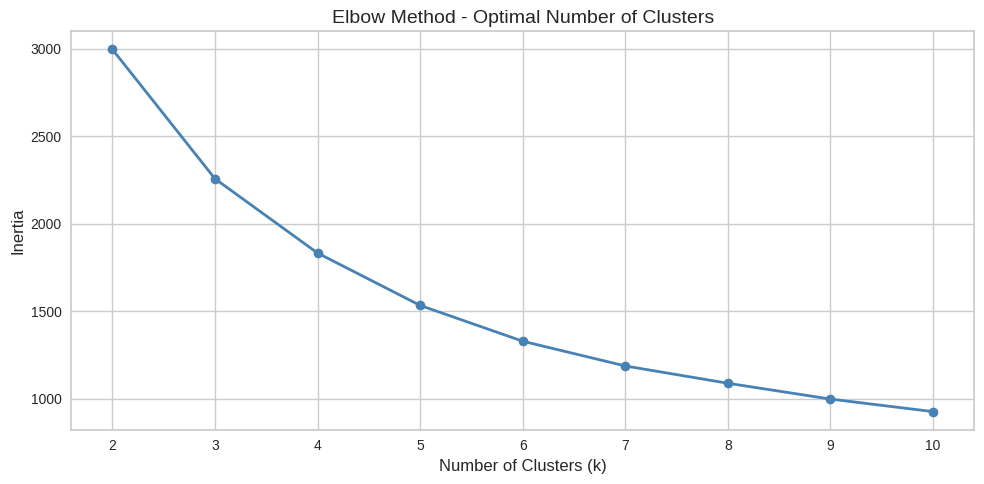

In [33]:
# Step 24: Elbow method to find optimal number of clusters
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker="o", color="steelblue", linewidth=2)
plt.title("Elbow Method - Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

k=2  Silhouette Score: 0.4298
k=3  Silhouette Score: 0.3311
k=4  Silhouette Score: 0.3340
k=5  Silhouette Score: 0.3128
k=6  Silhouette Score: 0.3098
k=7  Silhouette Score: 0.3065
k=8  Silhouette Score: 0.2781
k=9  Silhouette Score: 0.2844
k=10  Silhouette Score: 0.2796


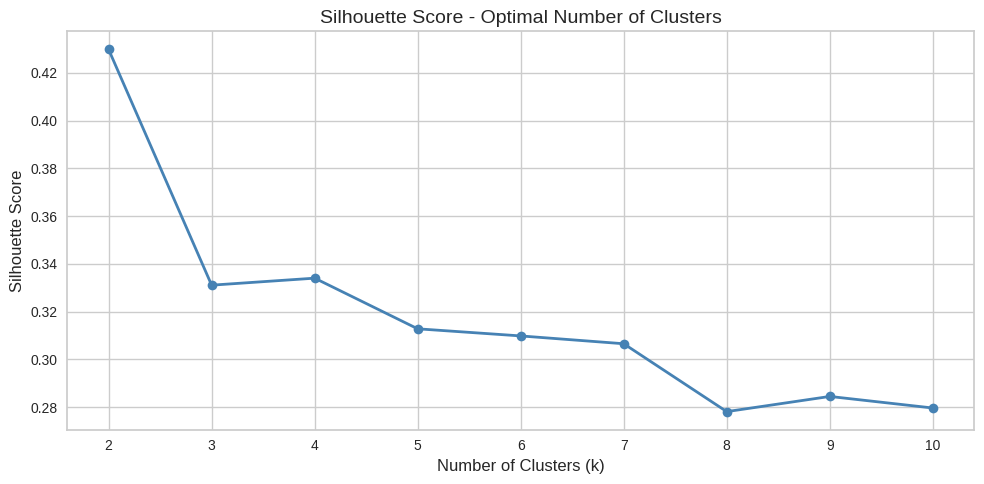

In [34]:
# Step 25: Silhouette scores for each k
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}  Silhouette Score: {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker="o", color="steelblue", linewidth=2)
plt.title("Silhouette Score - Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [35]:
# Step 26: Fit final K-Means model with k=4
kmeans_final = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=42)
rfm["KMeans_Cluster"] = kmeans_final.fit_predict(rfm_scaled)

print("=" * 60)
print("K-MEANS CLUSTERING COMPLETE - k=4")
print("=" * 60)
print(f"Inertia        : {kmeans_final.inertia_:.4f}")
print(f"Silhouette Score: {silhouette_score(rfm_scaled, rfm['KMeans_Cluster']):.4f}")
print(f"Davies-Bouldin  : {davies_bouldin_score(rfm_scaled, rfm['KMeans_Cluster']):.4f}")
print(f"Calinski-Harabasz: {calinski_harabasz_score(rfm_scaled, rfm['KMeans_Cluster']):.4f}")

print("\n" + "=" * 60)
print("CLUSTER SIZES")
print("=" * 60)
print(rfm["KMeans_Cluster"].value_counts().sort_index())

K-MEANS CLUSTERING COMPLETE - k=4
Inertia        : 1832.6744
Silhouette Score: 0.3340
Davies-Bouldin  : 1.0156
Calinski-Harabasz: 3286.6756

CLUSTER SIZES
KMeans_Cluster
0     727
1    1552
2     839
3    1220
Name: count, dtype: int64


In [36]:
# Step 27: Analyze RFM means per cluster
cluster_summary = rfm.groupby("KMeans_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

print("=" * 60)
print("CLUSTER PROFILE - MEAN RFM VALUES")
print("=" * 60)
print(cluster_summary)

print("\n" + "=" * 60)
print("CLUSTER PROFILE - MEDIAN RFM VALUES")
print("=" * 60)
print(rfm.groupby("KMeans_Cluster")[["Recency", "Frequency", "Monetary"]].median().round(2))

CLUSTER PROFILE - MEAN RFM VALUES
                Recency  Frequency  Monetary
KMeans_Cluster                              
0               12.7600    13.6000 8042.4800
1              183.0600     1.3000  309.1900
2               17.7900     2.2300  560.0200
3               76.3300     3.8900 1713.6200

CLUSTER PROFILE - MEDIAN RFM VALUES
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                9.0000    10.0000 3750.4000
1              177.5000     1.0000  277.4400
2               17.0000     2.0000  490.2200
3               59.0000     4.0000 1299.9200


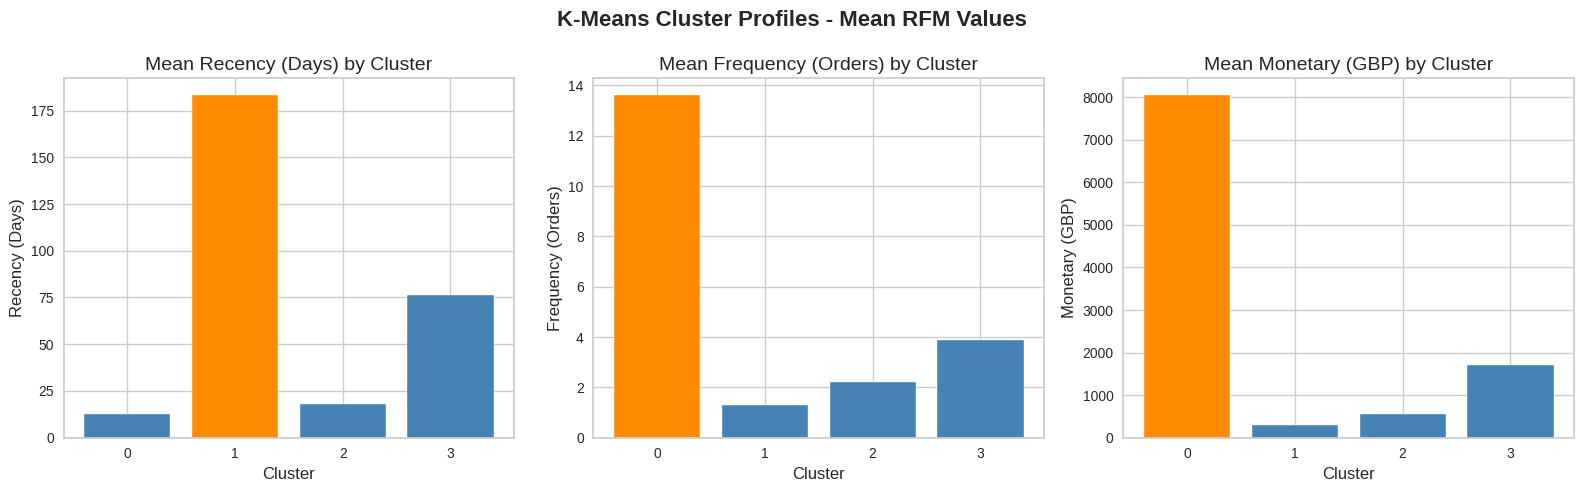

In [37]:
# Step 28: Visualize cluster profiles
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["Recency", "Frequency", "Monetary"]
titles  = ["Recency (Days)", "Frequency (Orders)", "Monetary (GBP)"]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    values = cluster_summary[metric]
    colors = ["steelblue" if v != values.max() else "darkorange" for v in values]
    axes[i].bar(cluster_summary.index, values, color=colors, edgecolor="white")
    axes[i].set_title(f"Mean {title} by Cluster")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(title)
    axes[i].set_xticks(cluster_summary.index)

plt.suptitle("K-Means Cluster Profiles - Mean RFM Values", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [38]:
# Step 29: Assign business labels to clusters based on RFM profile
segment_map = {
    0: "Champions",
    1: "Lost Customers",
    2: "New Customers",
    3: "Loyal Customers"
}

rfm["Segment"] = rfm["KMeans_Cluster"].map(segment_map)

print("=" * 60)
print("SEGMENT LABELS ASSIGNED")
print("=" * 60)
print(rfm["Segment"].value_counts())

print("\n" + "=" * 60)
print("SEGMENT PROFILE SUMMARY")
print("=" * 60)
print(rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(2))

SEGMENT LABELS ASSIGNED
Segment
Lost Customers     1552
Loyal Customers    1220
New Customers       839
Champions           727
Name: count, dtype: int64

SEGMENT PROFILE SUMMARY
                 Recency  Frequency  Monetary
Segment                                      
Champions        12.7600    13.6000 8042.4800
Lost Customers  183.0600     1.3000  309.1900
Loyal Customers  76.3300     3.8900 1713.6200
New Customers    17.7900     2.2300  560.0200


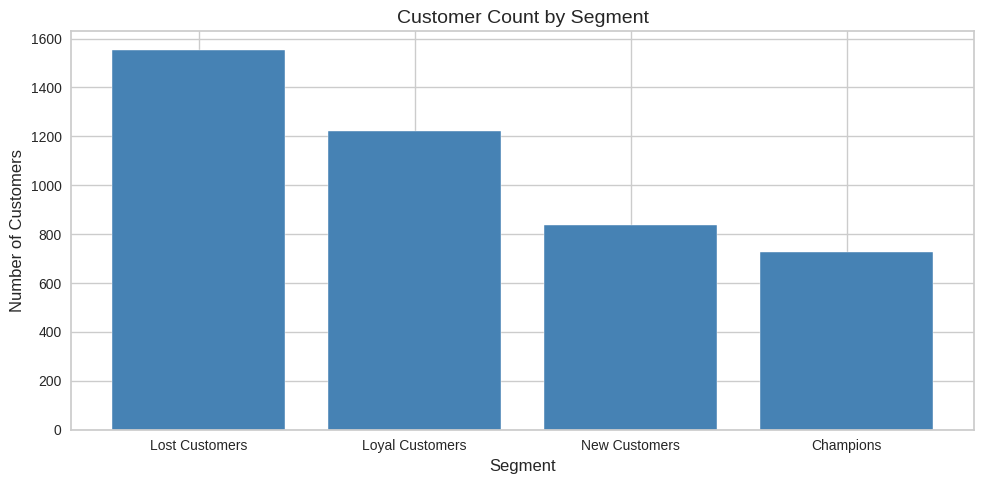

In [39]:
# Step 30: Plot segment distribution
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(segment_counts.index, segment_counts.values, color="steelblue", edgecolor="white")
plt.title("Customer Count by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

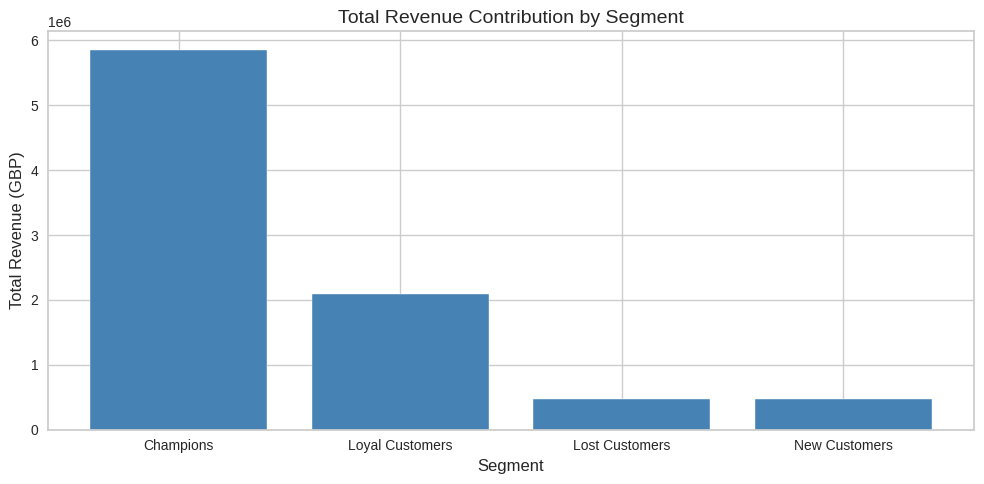

In [40]:
# Step 31: Plot revenue contribution by segment
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(segment_revenue.index, segment_revenue.values, color="steelblue", edgecolor="white")
plt.title("Total Revenue Contribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue (GBP)")
plt.tight_layout()
plt.show()

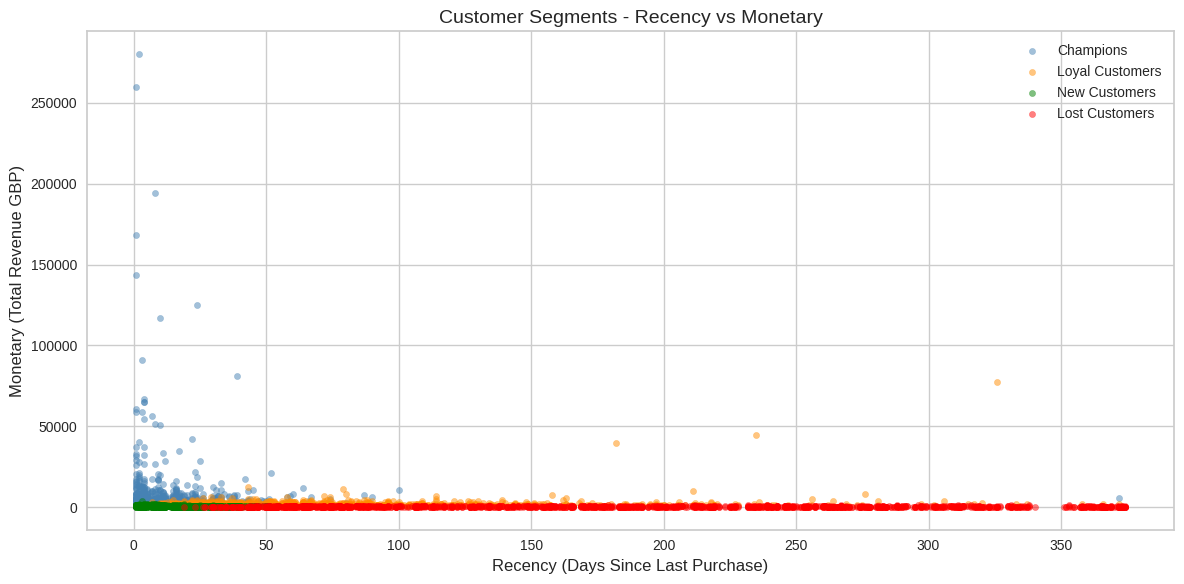

In [41]:
# Step 32: Plot RFM scatter - Recency vs Monetary colored by segment
colors = {
    "Champions"     : "steelblue",
    "Loyal Customers": "darkorange",
    "New Customers"  : "green",
    "Lost Customers" : "red"
}

plt.figure(figsize=(12, 6))
for segment, color in colors.items():
    subset = rfm[rfm["Segment"] == segment]
    plt.scatter(subset["Recency"], subset["Monetary"],
                label=segment, color=color, alpha=0.5, s=20)

plt.title("Customer Segments - Recency vs Monetary")
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Monetary (Total Revenue GBP)")
plt.legend()
plt.tight_layout()
plt.show()

## **Section 7: Hierarchical Clustering**

Hierarchical Clustering builds a tree of clusters (dendrogram) by iteratively
merging the most similar customers. Unlike K-Means it does not require specifying
k in advance and provides a visual representation of cluster structure.

We use Ward linkage which minimizes the total within-cluster variance at each
merge step. The optimal number of clusters is determined by cutting the dendrogram
at the point of the largest vertical distance between merges.

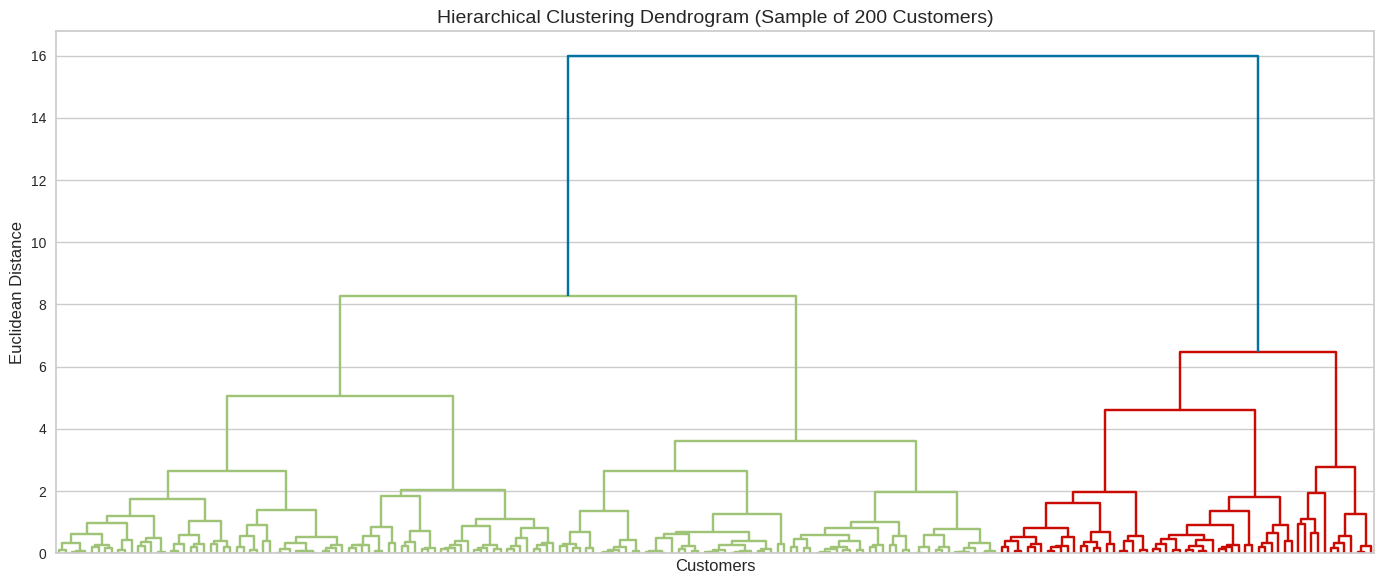

In [42]:
# Step 33: Plot dendrogram using a sample for readability
from scipy.cluster.hierarchy import dendrogram, linkage

sample_scaled = rfm_scaled.sample(n=200, random_state=42)
linked = linkage(sample_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linked,
           orientation="top",
           distance_sort="descending",
           show_leaf_counts=False,
           no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (Sample of 200 Customers)")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

In [43]:
# Step 34: Fit Agglomerative Hierarchical Clustering with k=4
hierarchical = AgglomerativeClustering(n_clusters=4, linkage="ward")
rfm["Hierarchical_Cluster"] = hierarchical.fit_predict(rfm_scaled)

print("=" * 60)
print("HIERARCHICAL CLUSTERING COMPLETE - k=4")
print("=" * 60)
print(f"Silhouette Score  : {silhouette_score(rfm_scaled, rfm['Hierarchical_Cluster']):.4f}")
print(f"Davies-Bouldin    : {davies_bouldin_score(rfm_scaled, rfm['Hierarchical_Cluster']):.4f}")
print(f"Calinski-Harabasz : {calinski_harabasz_score(rfm_scaled, rfm['Hierarchical_Cluster']):.4f}")

print("\n" + "=" * 60)
print("CLUSTER SIZES")
print("=" * 60)
print(rfm["Hierarchical_Cluster"].value_counts().sort_index())

print("\n" + "=" * 60)
print("CLUSTER PROFILE - MEAN RFM VALUES")
print("=" * 60)
print(rfm.groupby("Hierarchical_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2))

HIERARCHICAL CLUSTERING COMPLETE - k=4
Silhouette Score  : 0.2275
Davies-Bouldin    : 1.2293
Calinski-Harabasz : 2534.6093

CLUSTER SIZES
Hierarchical_Cluster
0    1769
1    1080
2    1119
3     370
Name: count, dtype: int64

CLUSTER PROFILE - MEAN RFM VALUES
                      Recency  Frequency   Monetary
Hierarchical_Cluster                               
0                    134.3900     1.2600   287.7100
1                     26.0300     5.3800  2502.1500
2                    118.9400     3.1500  1002.1800
3                      6.7000    18.8600 12309.4200


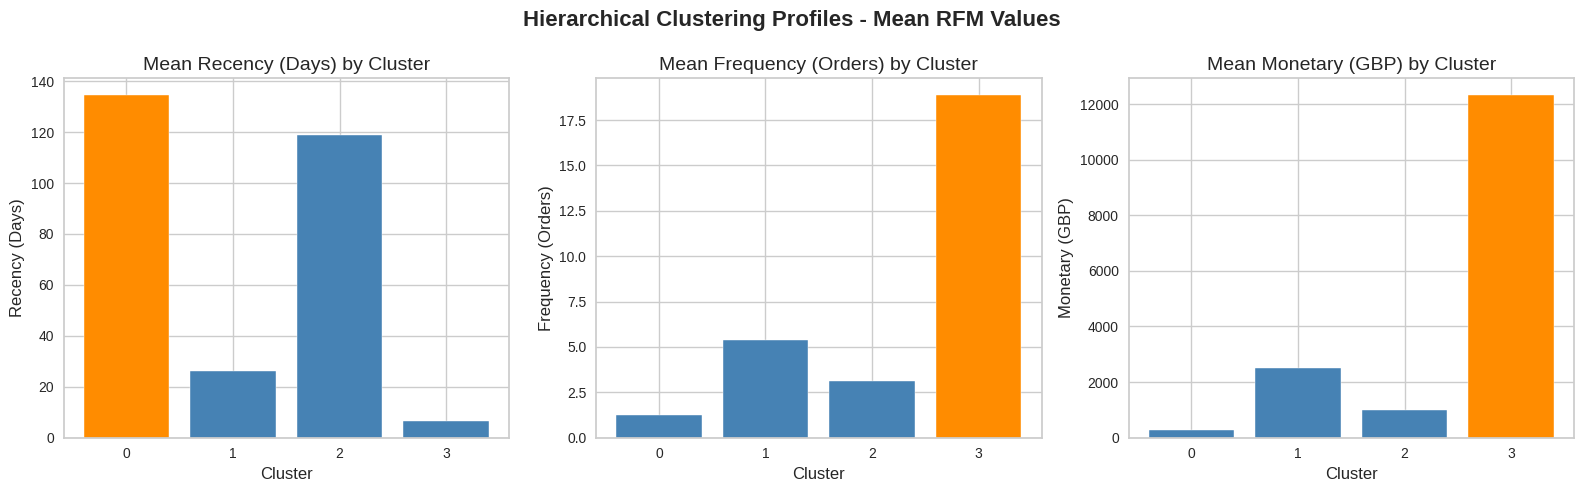

In [44]:
# Step 35: Plot Hierarchical cluster profiles
hier_summary = rfm.groupby("Hierarchical_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["Recency", "Frequency", "Monetary"]
titles  = ["Recency (Days)", "Frequency (Orders)", "Monetary (GBP)"]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    values = hier_summary[metric]
    colors = ["steelblue" if v != values.max() else "darkorange" for v in values]
    axes[i].bar(hier_summary.index, values, color=colors, edgecolor="white")
    axes[i].set_title(f"Mean {title} by Cluster")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(title)
    axes[i].set_xticks(hier_summary.index)

plt.suptitle("Hierarchical Clustering Profiles - Mean RFM Values", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## **Section 8: DBSCAN Clustering**

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) identifies
clusters as dense regions separated by sparse regions. Unlike K-Means and
Hierarchical Clustering it does not require specifying the number of clusters
in advance and can identify outliers as noise points (labeled -1).

Two key parameters control DBSCAN:
- epsilon (eps) : Maximum distance between two points to be considered neighbors
- min_samples   : Minimum number of points required to form a dense region

We use the k-distance graph method to determine the optimal epsilon value.

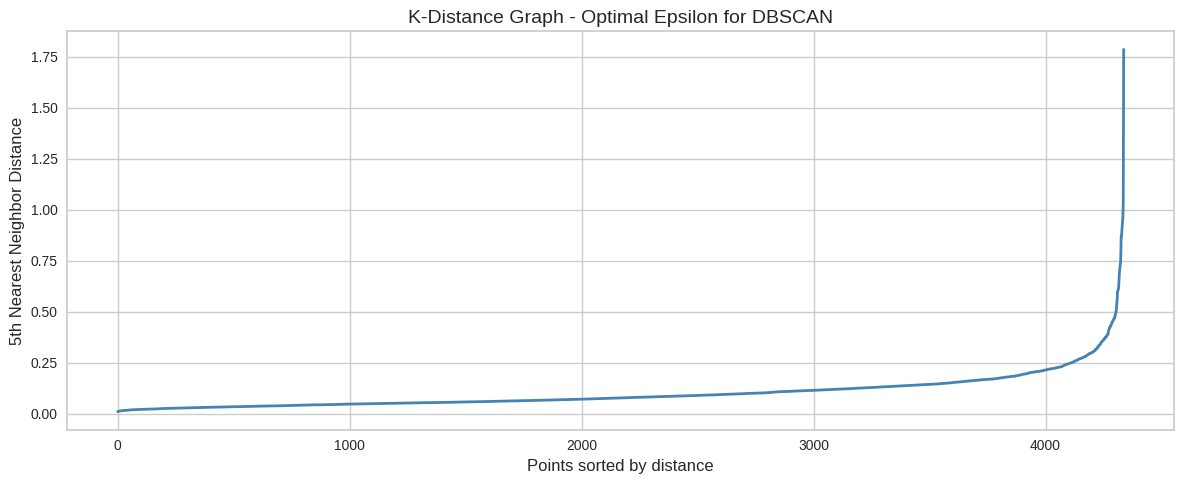

In [45]:
# Step 36: K-distance graph to find optimal epsilon for DBSCAN
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(rfm_scaled)
distances, indices = neighbors.kneighbors(rfm_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, color="steelblue", linewidth=2)
plt.title("K-Distance Graph - Optimal Epsilon for DBSCAN")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.tight_layout()
plt.show()

In [46]:
# Step 37: Fit DBSCAN model
dbscan = DBSCAN(eps=0.25, min_samples=5)
rfm["DBSCAN_Cluster"] = dbscan.fit_predict(rfm_scaled)

print("=" * 60)
print("DBSCAN CLUSTERING COMPLETE")
print("=" * 60)
print(f"Epsilon      : 0.25")
print(f"Min Samples  : 5")

print("\n" + "=" * 60)
print("CLUSTER SIZES")
print("=" * 60)
print(rfm["DBSCAN_Cluster"].value_counts().sort_index())

print("\n" + "=" * 60)
print("NOISE POINTS")
print("=" * 60)
noise = (rfm["DBSCAN_Cluster"] == -1).sum()
print(f"Noise points identified : {noise:,}")
print(f"Percentage of customers : {noise/len(rfm)*100:.2f}%")

DBSCAN CLUSTERING COMPLETE
Epsilon      : 0.25
Min Samples  : 5

CLUSTER SIZES
DBSCAN_Cluster
-1     130
 0    1904
 1    1471
 2     824
 3       4
 4       5
Name: count, dtype: int64

NOISE POINTS
Noise points identified : 130
Percentage of customers : 3.00%


In [47]:
# Step 38: Analyze DBSCAN cluster profiles
print("=" * 60)
print("DBSCAN CLUSTER PROFILE - MEAN RFM VALUES")
print("=" * 60)
print(rfm.groupby("DBSCAN_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2))

print("\n" + "=" * 60)
print("DBSCAN CLUSTER PROFILE - MEDIAN RFM VALUES")
print("=" * 60)
print(rfm.groupby("DBSCAN_Cluster")[["Recency", "Frequency", "Monetary"]].median().round(2))

DBSCAN CLUSTER PROFILE - MEAN RFM VALUES
                Recency  Frequency   Monetary
DBSCAN_Cluster                               
-1              67.2500    21.1800 24603.7400
 0              43.7500     6.5600  2385.2000
 1             157.3600     1.0000   342.1200
 2              93.9700     2.0000   650.0000
 3             103.0000     1.0000  4390.9800
 4               9.2000    35.0000 18175.6400

DBSCAN CLUSTER PROFILE - MEDIAN RFM VALUES
                Recency  Frequency   Monetary
DBSCAN_Cluster                               
-1              19.5000     8.0000  7831.1800
 0              24.0000     5.0000  1605.9100
 1             134.0000     1.0000   255.9000
 2              61.0000     2.0000   543.7600
 3             100.5000     1.0000  4340.7500
 4               9.0000    34.0000 17654.5400


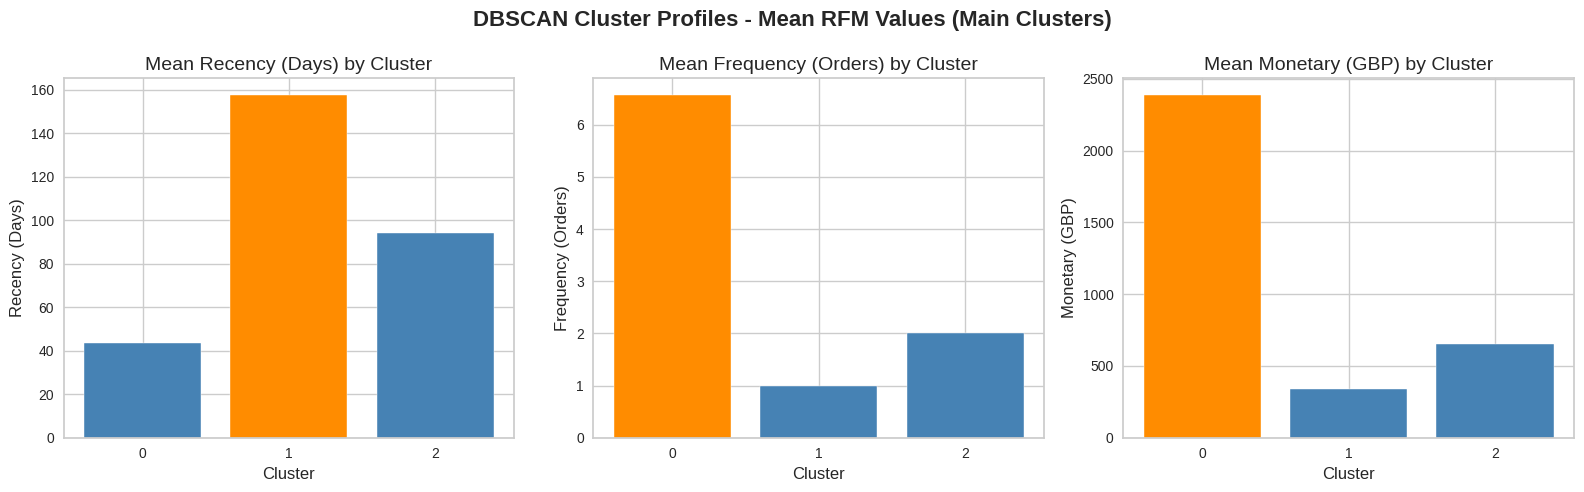

In [49]:
# Step 39: Plot DBSCAN cluster profiles for main clusters only
dbscan_summary = rfm[rfm["DBSCAN_Cluster"].isin([0, 1, 2])].groupby(
    "DBSCAN_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["Recency", "Frequency", "Monetary"]
titles  = ["Recency (Days)", "Frequency (Orders)", "Monetary (GBP)"]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    values = dbscan_summary[metric]
    colors = ["steelblue" if v != values.max() else "darkorange" for v in values]
    axes[i].bar(dbscan_summary.index, values, color=colors, edgecolor="white")
    axes[i].set_title(f"Mean {title} by Cluster")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(title)
    axes[i].set_xticks(dbscan_summary.index)

plt.suptitle("DBSCAN Cluster Profiles - Mean RFM Values (Main Clusters)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## **Section 9: Clustering Algorithm Comparison and Evaluation**

We compare all three clustering algorithms across three internal validation metrics:

- Silhouette Score        : Higher is better. Measures cluster cohesion and separation.
- Davies-Bouldin Score    : Lower is better. Measures average similarity between clusters.
- Calinski-Harabasz Score : Higher is better. Measures ratio of between-cluster to
                            within-cluster dispersion.

DBSCAN evaluation excludes noise points labeled as -1.

In [50]:
# Step 40: Compare all three clustering algorithms
dbscan_mask = rfm["DBSCAN_Cluster"] != -1

results = {
    "Algorithm"          : ["K-Means", "Hierarchical", "DBSCAN"],
    "Silhouette Score"   : [
        silhouette_score(rfm_scaled, rfm["KMeans_Cluster"]),
        silhouette_score(rfm_scaled, rfm["Hierarchical_Cluster"]),
        silhouette_score(rfm_scaled[dbscan_mask], rfm.loc[dbscan_mask, "DBSCAN_Cluster"])
    ],
    "Davies-Bouldin"     : [
        davies_bouldin_score(rfm_scaled, rfm["KMeans_Cluster"]),
        davies_bouldin_score(rfm_scaled, rfm["Hierarchical_Cluster"]),
        davies_bouldin_score(rfm_scaled[dbscan_mask], rfm.loc[dbscan_mask, "DBSCAN_Cluster"])
    ],
    "Calinski-Harabasz"  : [
        calinski_harabasz_score(rfm_scaled, rfm["KMeans_Cluster"]),
        calinski_harabasz_score(rfm_scaled, rfm["Hierarchical_Cluster"]),
        calinski_harabasz_score(rfm_scaled[dbscan_mask], rfm.loc[dbscan_mask, "DBSCAN_Cluster"])
    ]
}

results_df = pd.DataFrame(results).set_index("Algorithm").round(4)

print("=" * 60)
print("CLUSTERING ALGORITHM COMPARISON")
print("=" * 60)
print(results_df)

CLUSTERING ALGORITHM COMPARISON
              Silhouette Score  Davies-Bouldin  Calinski-Harabasz
Algorithm                                                        
K-Means                 0.3340          1.0156          3286.6756
Hierarchical            0.2275          1.2293          2534.6093
DBSCAN                  0.1034          1.2507          1037.8617


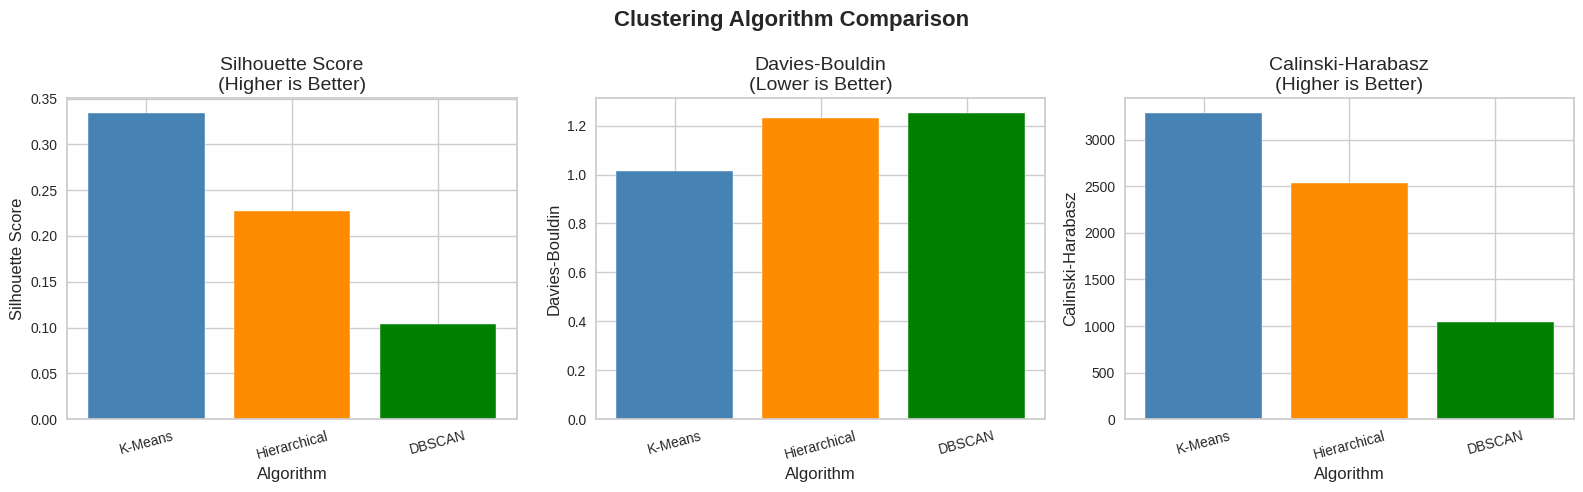

In [51]:
# Step 41: Visualize algorithm comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics  = ["Silhouette Score", "Davies-Bouldin", "Calinski-Harabasz"]
better   = ["Higher is Better", "Lower is Better", "Higher is Better"]
colors   = ["steelblue", "darkorange", "green"]

for i, (metric, note) in enumerate(zip(metrics, better)):
    axes[i].bar(results_df.index, results_df[metric], color=colors, edgecolor="white")
    axes[i].set_title(f"{metric}\n({note})")
    axes[i].set_xlabel("Algorithm")
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis="x", rotation=15)

plt.suptitle("Clustering Algorithm Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## **Section 10: Business Interpretation and Managerial Insights**

Based on the K-Means clustering results which produced the best statistical
performance, we derive actionable marketing strategies for each customer segment.

The four segments identified are:

- Champions      : Most valuable customers. purchased recently, buy often, spend most.
- Loyal Customers: Purchase regularly and spend well but not as active as Champions.
- New Customers  : Purchased recently but low frequency and moderate spend.
- Lost Customers : Have not purchased in a long time, low frequency, low spend.

In [52]:
# Step 42: Final segment summary table
final_summary = rfm.groupby("Segment").agg(
    Customer_Count = ("CustomerID",  "count"),
    Avg_Recency    = ("Recency",     "mean"),
    Avg_Frequency  = ("Frequency",   "mean"),
    Avg_Monetary   = ("Monetary",    "mean"),
    Total_Revenue  = ("Monetary",    "sum")
).round(2)

final_summary["Revenue_Share_%"] = (
    final_summary["Total_Revenue"] / final_summary["Total_Revenue"].sum() * 100
).round(2)

print("=" * 60)
print("FINAL SEGMENT SUMMARY")
print("=" * 60)
print(final_summary)

FINAL SEGMENT SUMMARY
                 Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Segment                                                                     
Champions                   727      12.7600        13.6000     8042.4800   
Lost Customers             1552     183.0600         1.3000      309.1900   
Loyal Customers            1220      76.3300         3.8900     1713.6200   
New Customers               839      17.7900         2.2300      560.0200   

                 Total_Revenue  Revenue_Share_%  
Segment                                          
Champions         5846881.6300          65.7900  
Lost Customers     479860.3100           5.4000  
Loyal Customers   2090612.2300          23.5200  
New Customers      469854.7200           5.2900  


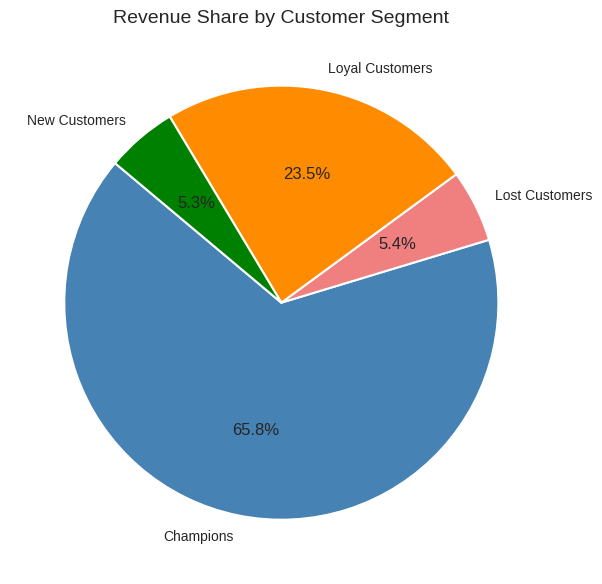

In [53]:
# Step 43: Plot revenue share by segment as pie chart
revenue_share = final_summary["Revenue_Share_%"]

plt.figure(figsize=(10, 6))
plt.pie(revenue_share.values,
        labels=revenue_share.index,
        autopct="%1.1f%%",
        colors=["steelblue", "lightcoral", "darkorange", "green"],
        startangle=140,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
plt.title("Revenue Share by Customer Segment")
plt.tight_layout()
plt.show()

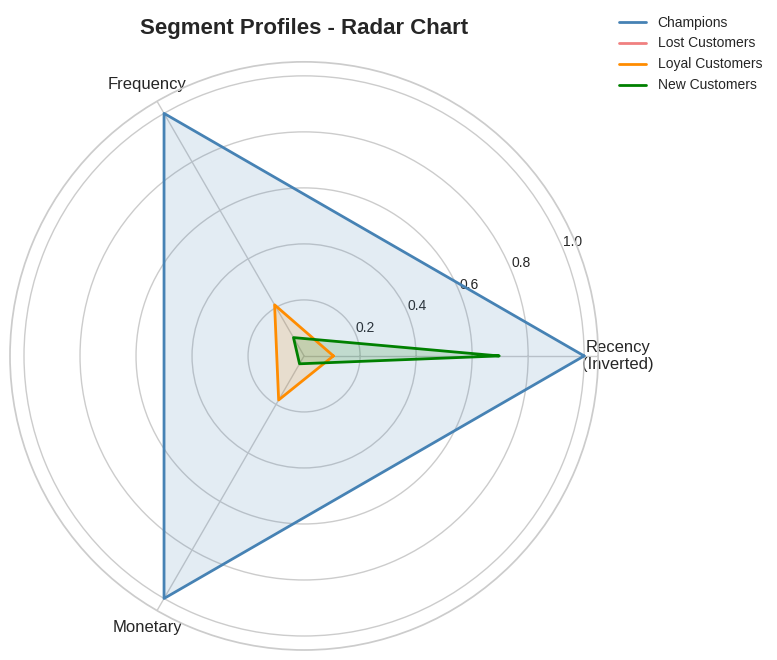

In [54]:
# Step 44: Plot radar chart for segment profiles
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ["Recency\n(Inverted)", "Frequency", "Monetary"]

# Normalize RFM for radar chart (invert recency so higher = better)
radar_data = final_summary[["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]].copy()
radar_data["Avg_Recency"] = 1 / radar_data["Avg_Recency"]

for col in radar_data.columns:
    radar_data[col] = (radar_data[col] - radar_data[col].min()) / (
        radar_data[col].max() - radar_data[col].min())

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ["steelblue", "lightcoral", "darkorange", "green"]
segments = radar_data.index.tolist()

for i, (segment, color) in enumerate(zip(segments, colors)):
    values = radar_data.loc[segment].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=segment)
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_title("Segment Profiles - Radar Chart", size=16, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## **Section 11: Conclusion and Research Implications**

### **Summary of Findings**

This project applied the RFM framework combined with three unsupervised machine
learning algorithms to segment 4,338 customers from a real-world e-commerce
dataset spanning December 2010 to December 2011.

### **Clustering Performance**

K-Means outperformed Hierarchical Clustering and DBSCAN across all three
evaluation metrics: Silhouette Score (0.334), Davies-Bouldin Score (1.016),
and Calinski-Harabasz Score (3286.68). K-Means was selected as the final model.

### **Customer Segments Identified**

| Segment         | Customers | Avg Recency | Avg Frequency | Avg Monetary | Revenue Share |
|-----------------|-----------|-------------|---------------|--------------|---------------|
| Champions       | 727       | 13 days     | 14 orders     | GBP 8,042    | 65.79%        |
| Loyal Customers | 1,220     | 76 days     | 4 orders      | GBP 1,714    | 23.52%        |
| New Customers   | 839       | 18 days     | 2 orders      | GBP 560      | 5.29%         |
| Lost Customers  | 1,552     | 183 days    | 1 order       | GBP 309      | 5.40%         |

### **Managerial Implications**

- Champions generate 65.79% of total revenue from only 16.76% of customers.
  Priority should be retention through exclusive loyalty programs and early
  access to new products.

- Loyal Customers contribute 23.52% of revenue and represent the highest
  growth opportunity. Targeted upselling and cross-selling campaigns can
  convert them into Champions.

- New Customers have purchased recently but low frequency suggests they have
  not yet developed a purchase habit. Onboarding campaigns and first repeat
  purchase incentives are critical within the first 30 days.

- Lost Customers represent 35.78% of the customer base but only 5.40% of
  revenue. Win-back campaigns with strong discounts may recover a portion
  but marketing spend should be carefully evaluated against expected return.

In [55]:
# Step 45: Export final segmented customer table
output = rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Segment"]].copy()
output.to_csv("/content/customer_segments.csv", index=False)

print("=" * 60)
print("FINAL OUTPUT SAVED")
print("=" * 60)
print(f"File     : /content/customer_segments.csv")
print(f"Rows     : {len(output):,}")
print(f"Columns  : {list(output.columns)}")
print(f"\nSample output:")
print(output.head(10))

FINAL OUTPUT SAVED
File     : /content/customer_segments.csv
Rows     : 4,338
Columns  : ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']

Sample output:
   CustomerID  Recency  Frequency   Monetary          Segment
0       12346      326          1 77183.6000  Loyal Customers
1       12347        2          7  4310.0000        Champions
2       12348       75          4  1797.2400  Loyal Customers
3       12349       19          1  1757.5500    New Customers
4       12350      310          1   334.4000   Lost Customers
5       12352       36          8  2506.0400  Loyal Customers
6       12353      204          1    89.0000   Lost Customers
7       12354      232          1  1079.4000   Lost Customers
8       12355      214          1   459.4000   Lost Customers
9       12356       23          3  2811.4300  Loyal Customers


## **Project Complete - What Was Built**
The notebook covers 11 sections and 45 steps end to end:

- Data fetched directly from Kaggle API into Google Colab
- 149,217 records cleaned across 5 cleaning steps, retaining 72.46% of data
- Full EDA with 5 visualizations covering transactions, revenue, geography and products
- RFM features engineered from scratch with log transformation to correct skewness
- Three clustering algorithms applied and evaluated: K-Means, Hierarchical, DBSCAN
- K-Means selected as best model with Silhouette 0.334 and Calinski-Harabasz 3286.68
- Four business segments identified with clear marketing strategies
- Champions: 727 customers generating 65.79% of total revenue
- Final segmented dataset exported as CSV